In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from src.data_ingestion import dfs, load_from_gcs, train_df, test_df


In [2]:
train_df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                          7

In [4]:
train_df.isna().sum()

id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0


In [5]:
# Duplicates
train_df.duplicated().sum()

np.int64(0)

In [6]:
# Statistical Analysis
train_df.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# Categorical Cols
train_df.describe(include = 'O')

C:\Users\pasup\AppData\Local\Temp\ipykernel_41056\1973763634.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train_df.describe(include = 'O')


,gender,ethnicity,education_level,income_level,smoking_status,employment_status
count,700000,700000,700000,700000,700000,700000
unique,3,5,4,5,3,4
top,Female,White,Highschool,Middle,Never,Employed
freq,363237,386153,344145,290557,494448,516170


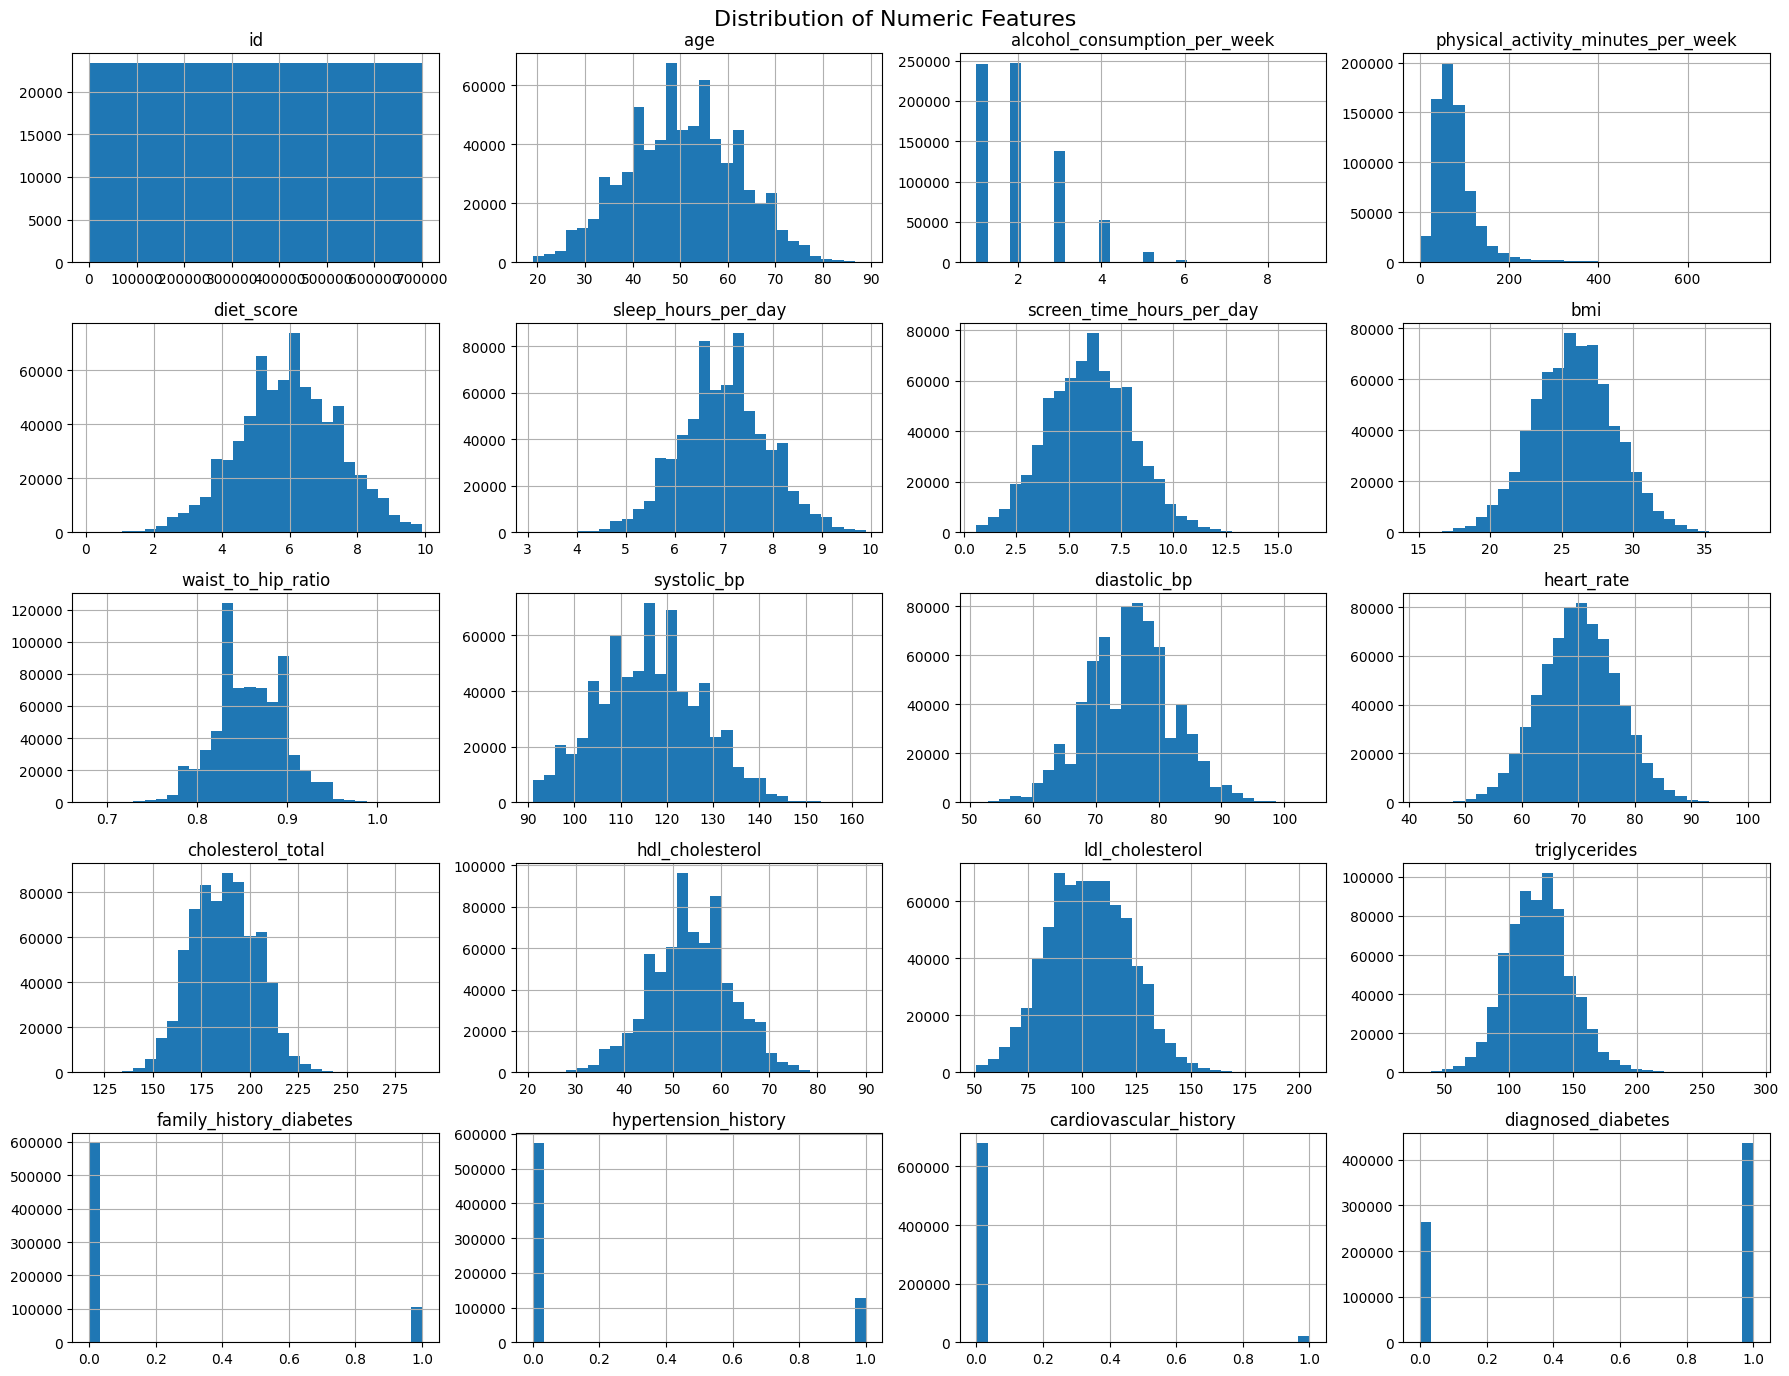

In [18]:
# Data Distribution
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns

train_df[numeric_cols].hist(
    bins=30,
    figsize=(18, 14),
    layout=(5, 4)  # adjust rows x cols
)

plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()


In [9]:
scale_cols = [
    "age",
    "diet_score",
    "sleep_hours_per_day",
    "screen_time_hours_per_day",
    "waist_to_hip_ratio",
    "bmi",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "cholesterol_total",
    "hdl_cholesterol",
    "ldl_cholesterol",
    "triglycerides"
]

skewed_cols =  [  "alcohol_consumption_per_week",
    "physical_activity_minutes_per_week"
]

In [10]:
cat_cols = train_df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    print(f"\n{col}")
    display(train_df[col].value_counts(normalize=True).round(2).head(10))


gender


C:\Users\pasup\AppData\Local\Temp\ipykernel_41056\2443116047.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include=['object', 'category']).columns


gender
Female    0.52
Male      0.48
Other     0.01
Name: proportion, dtype: float64


ethnicity


ethnicity
White       0.55
Hispanic    0.19
Black       0.15
Asian       0.09
Other       0.02
Name: proportion, dtype: float64

...

income_level
Middle          0.42
Lower-Middle    0.26
Upper-Middle    0.18
Low             0.12
High            0.02
Name: proportion, dtype: float64


smoking_status


smoking_status
Never      0.71
Current    0.15
Former     0.15
Name: proportion, dtype: float64


employment_status


employment_status
Employed      0.74
Retired       0.17
Unemployed    0.07
Student       0.03
Name: proportion, dtype: float64

In [11]:
# Outlier Detection

def iqr_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

for col in scale_cols:
    outliers = iqr_outliers(train_df, col)
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(train_df):.2%})")


age: 1013 outliers (0.14%)
diet_score: 1997 outliers (0.29%)
sleep_hours_per_day: 6152 outliers (0.88%)
screen_time_hours_per_day: 2337 outliers (0.33%)
waist_to_hip_ratio: 6159 outliers (0.88%)
bmi: 4254 outliers (0.61%)
systolic_bp: 775 outliers (0.11%)
diastolic_bp: 5752 outliers (0.82%)
heart_rate: 1797 outliers (0.26%)
cholesterol_total: 1771 outliers (0.25%)
hdl_cholesterol: 4693 outliers (0.67%)
ldl_cholesterol: 2290 outliers (0.33%)
triglycerides: 9053 outliers (1.29%)


In [12]:
# Skewed columns outlires
for col in skewed_cols:
    outliers = iqr_outliers(train_df, col)
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(train_df):.2%})")

alcohol_consumption_per_week: 509 outliers (0.07%)
physical_activity_minutes_per_week: 33490 outliers (4.78%)


- <1% → ignore

- 1–5% → cap (winsorise)

- 5% → investigate

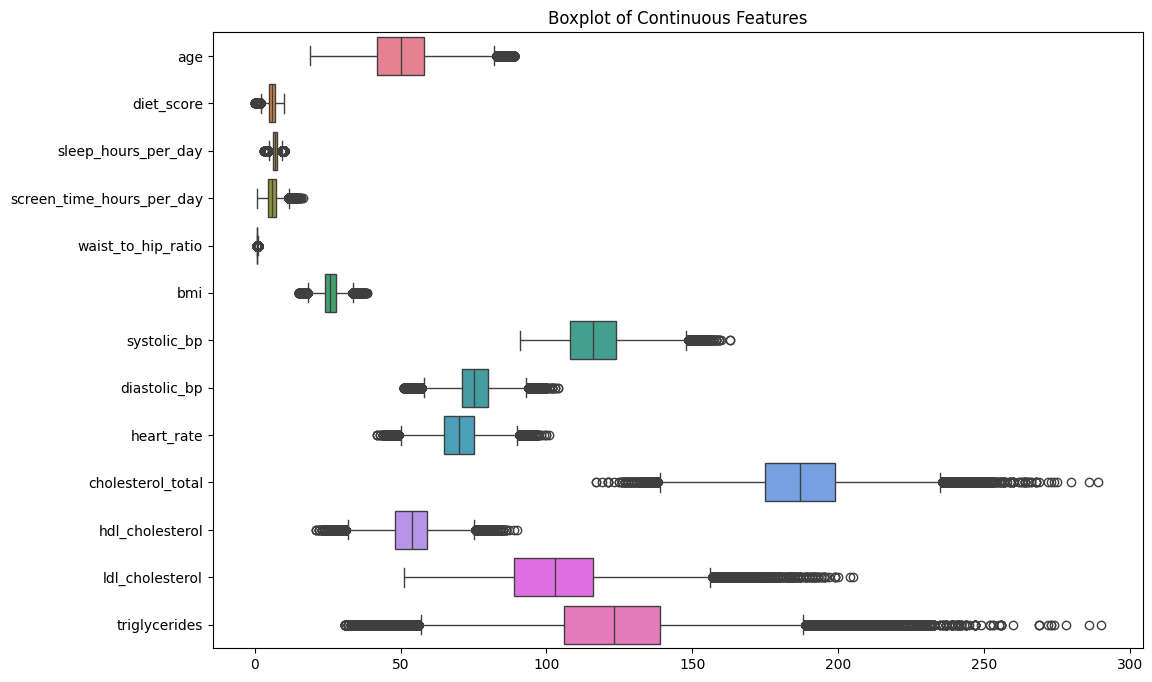

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.boxplot(data=train_df[scale_cols], orient="h")
plt.title("Boxplot of Continuous Features")
plt.show()


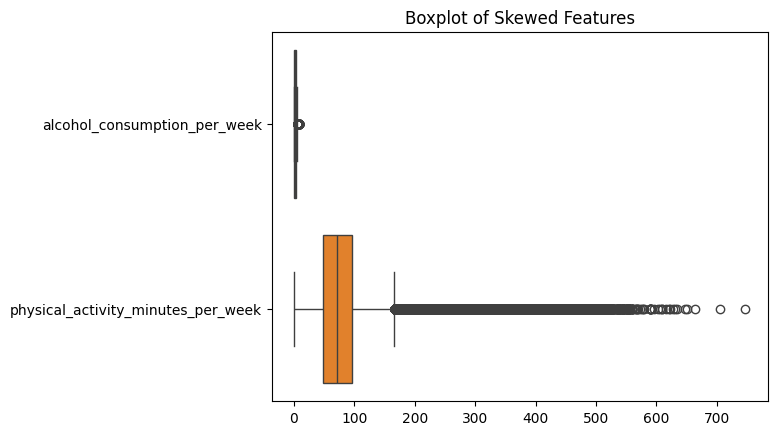

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=train_df[skewed_cols], orient="h")
plt.title("Boxplot of Skewed Features")
plt.show()

<Axes: >

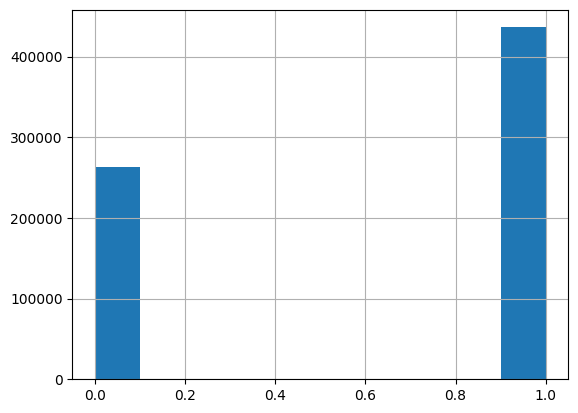

In [15]:
train_df['diagnosed_diabetes'].hist()

In [ ]:
# Observing Target Variable for Imbalance - Considered as Balance since 60-40% ratio
train_df['diagnosed_diabetes'].value_counts(normalize=True)*100

diagnosed_diabetes
1.0    62.329571
0.0    37.670429
Name: proportion, dtype: float64